# ResNet TOV Emulator to predict Mass, Radius and Tidal Deformability of a Neutron Strar from a PP EOS - Final

### <div style= 'color: orange'> Import all the required modules

In [1]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

import os
import torch
import itertools
import random
import time

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader, TensorDataset
from scipy.interpolate import interp1d
from tqdm import trange
from numba import jit
from tracemalloc import start
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from TOV4_f_files import tov_4   # your f2py module
%matplotlib widget

### <div style= 'color: orange'> Global constants and unit conversion factors

In [2]:
msun=147660                 # Solar mass in cm given by the formula G*M_sun/c^2

c=2.9979e10                 # speed of light in cm/s (CGS)
G=6.67408e-8                # gravitational constant in cm^3/gm/s^2 (CGS)

dkm = 1.3234e-06            # conversion of MeV/fm^3 to km^-2
dcgs = 1.78e12              # factor to convert from MeV/fm^3 to gm/cm^3
conv = 8.2601e-40           # dyn/cm^2 to km^-2
cgs1=1.7827e+12             # MeV/fm3 to gms/cm3
cgs2=1.6022e+33             # MeV/fm3 to dyne/cm2

### <div style= 'color: orange'>4 Piecewise-polytrope low-density (crust) parameters

In [3]:
# Low density Polytropic exponents
GammaL_1 = 1.35692
GammaL_2 = 0.62223
GammaL_3 = 1.28733
GammaL_4 = 1.58425

# Low density Polytropic constants
KL_1 = 3.99874e-8 # * pow(Msun/Length**3, GammaL_1-1)
KL_2 = 5.32697e+1 # * pow(Msun/Length**3, GammaL_2-1)
KL_3 = 1.06186e-6 # * pow(Msun/Length**3, GammaL_3-1)
KL_4 = 6.80110e-9 # * pow(Msun/Length**3, GammaL_4-1)
# notice a missing c^2 in Ki values in Table II of Read et al. 2009

# Densities at the boundaries of the low density piecewise polytropes
rhoL_1 = 2.62789e12
rhoL_2 = 3.78358e11
rhoL_3 = 2.44034e7
rhoL_4 = 0.0

# Pressures at the boundaries of the low density piecewise polytropes
pL_1 = KL_1*rhoL_1**GammaL_1
pL_2 = KL_2*rhoL_2**GammaL_2
pL_3 = KL_3*rhoL_3**GammaL_3
pL_4 = 0.0

# The exact numbers are taken from a particular crust model/table.

### <div style= 'color: orange'> Low density Energy density, α, and Break densities

In [4]:
# Compute the offsets specific internal energy (epsL_i) and alphaL_i at the 
# boundaries
# The general form used: ε(ρ)=(1+α)ρ+K/(Γ−1)ρ^Γ. 
# Solving for alpha ensures matching across boundaries.
# Energy density needs an additive offset to enforce continuity.

epsL_4 = 0.0
alphaL_4 = 0.0
epsL_3 = (1+alphaL_4)*rhoL_3 + KL_4/(GammaL_4 - 1.)*pow(rhoL_3, GammaL_4)
alphaL_3 = epsL_3/rhoL_3 - 1.0 - KL_3/(GammaL_3 - 1.)*pow(rhoL_3, GammaL_3 -1.0)
epsL_2 = (1+alphaL_3)*rhoL_2 + KL_3/(GammaL_3 - 1.)*pow(rhoL_2, GammaL_3)
alphaL_2 = epsL_2/rhoL_2 - 1.0 - KL_2/(GammaL_2 - 1.)*pow(rhoL_2, GammaL_2 -1.0)
epsL_1 = (1+alphaL_2)*rhoL_1 + KL_2/(GammaL_2 - 1.)*pow(rhoL_1, GammaL_2)
alphaL_1 = epsL_1/rhoL_1 - 1.0 - KL_1/(GammaL_1 - 1.)*pow(rhoL_1, GammaL_1 -1.0)

# Density thresholds for high-density polytropes
rho1 = pow(10,14.7) # Break Density 1
rho2 = pow(10,15.0) # Break Density 2

# GR conversion prefactors to go from cgs pressure/energy-density units into 
# geometric units (where G=c=1)
t_p=G/c**4
t_rho=G/c**2

### <div style= 'color: orange'> Forward EOS: ρ↦(p,ε)
To calculate pressure and energy density for polytropes based on the central density region of intrest

In [5]:
def p_eps_of_rho(rho,logp,Gamma1,Gamma2,Gamma3):
    p1 = pow(10.0,logp)/c**2
    K1 = p1/pow(rho1,Gamma1)
    K2 = K1 * pow( rho1, Gamma1-Gamma2)
    K3 = K2 * pow( rho2, Gamma2-Gamma3)
    rho0 = pow(KL_1/K1,1.0/(Gamma1-GammaL_1)) 
    eps0 = (1.0+alphaL_1)*rho0 + KL_1/(GammaL_1-1.0)*pow(rho0,GammaL_1)
    alpha1 = eps0/rho0 - 1.0 - K1/(Gamma1 - 1.0)*pow(rho0, Gamma1 -1.0)
    eps1 = (1.0+alpha1)*rho1 + K1/(Gamma1 - 1.0)*pow(rho1, Gamma1)
    alpha2 = eps1/rho1 - 1.0 - K2/(Gamma2 - 1.0)*pow(rho1, Gamma2 -1.0)
    eps2 = (1.0+alpha2)*rho2 + K2/(Gamma2 - 1.0)*pow(rho2, Gamma2)
    alpha3 = eps2/rho2 - 1.0 - K3/(Gamma3 - 1.0)*pow(rho2, Gamma3 -1.0)
    if rho<rhoL_3:
        p = KL_4*pow(rho,GammaL_4)
        eps = (1.0+alphaL_4)*rho + KL_4/(GammaL_4-1.0)*pow(rho,GammaL_4)
    elif rhoL_3<= rho <rhoL_2:
        p = KL_3*pow(rho,GammaL_3)
        eps = (1.0+alphaL_3)*rho + KL_3/(GammaL_3-1.0)*pow(rho,GammaL_3)
    elif rhoL_2<= rho <rhoL_1:
        p = KL_2*pow(rho,GammaL_2)
        eps = (1.0+alphaL_2)*rho + KL_2/(GammaL_2-1.0)*pow(rho,GammaL_2)
    elif rhoL_1<= rho <rho0:
        p = KL_1*pow(rho,GammaL_1)
        eps = (1.0+alphaL_1)*rho + KL_1/(GammaL_1-1.0)*pow(rho,GammaL_1)
    elif rho0<= rho <rho1:
        p = K1*pow(rho,Gamma1)
        eps = (1.0+alpha1)*rho + K1/(Gamma1-1.0)*pow(rho,Gamma1)
    elif rho1<= rho <rho2:
        p = K2*pow(rho,Gamma2)
        eps = (1.0+alpha2)*rho + K2/(Gamma2-1.0)*pow(rho,Gamma2)
    else:
        p = K3*pow(rho,Gamma3)
        eps = (1.0+alpha3)*rho + K3/(Gamma3-1.0)*pow(rho,Gamma3)
    return p*c**2, eps*c**2

### <div style= 'color: orange'> Inverse EOS: p↦ε
To calculate Energy denisty for every log pressure value of intrest 
while solving a polytrope

In [6]:
@jit(nopython=True)
def eps(p,logp,Gamma1,Gamma2,Gamma3):
    p1 = pow(10.0,logp)/c**2
    p*=1/c**2
    K1 = p1/pow(rho1,Gamma1)
    K2 = K1 * pow( rho1, Gamma1-Gamma2)
    K3 = K2 * pow( rho2, Gamma2-Gamma3)
    rho0 = pow(KL_1/K1,1.0/(Gamma1-GammaL_1))
    eps0 = (1.0+alphaL_1)*rho0 + KL_1/(GammaL_1-1.0)*pow(rho0,GammaL_1)
    alpha1 = eps0/rho0 - 1.0 - K1/(Gamma1 - 1.0)*pow(rho0, Gamma1 -1.0)
    eps1 = (1.0+alpha1)*rho1 + K1/(Gamma1 - 1.0)*pow(rho1, Gamma1)
    alpha2 = eps1/rho1 - 1.0 - K2/(Gamma2 - 1.0)*pow(rho1, Gamma2 -1.0)
    eps2 = (1.0+alpha2)*rho2 + K2/(Gamma2 - 1.0)*pow(rho2, Gamma2)
    alpha3 = eps2/rho2 - 1.0 - K3/(Gamma3 - 1.0)*pow(rho2, Gamma3 -1.0)
    p0 = K1*pow(rho0,Gamma1)
    p2 = K3*pow(rho2,Gamma3)
    if  p<pL_3:
        rho = pow(p/KL_4,1/GammaL_4)
        eps = (1.0+alphaL_4)*rho + KL_4/(GammaL_4-1.0)*pow(rho,GammaL_4)
    elif pL_3<= p <pL_2:
        rho = pow(p/KL_3,1/GammaL_3)
        eps = (1.0+alphaL_3)*rho + KL_3/(GammaL_3-1.0)*pow(rho,GammaL_3)
    elif pL_2<= p <pL_1:
        rho = pow(p/KL_2,1/GammaL_2)
        eps = (1.0+alphaL_2)*rho + KL_2/(GammaL_2-1.0)*pow(rho,GammaL_2)
    elif  pL_1<p <p0:
        rho = pow(p/KL_1,1/GammaL_1)
        eps = (1.0+alphaL_1)*rho + KL_1/(GammaL_1-1.0)*pow(rho,GammaL_1)
    elif p0<= p <p1:
        rho = pow(p/K1,1/Gamma1)
        eps = (1.0+alpha1)*rho + K1/(Gamma1-1.0)*pow(rho,Gamma1)
    elif p1<= p <p2:
        rho = pow(p/K2,1/Gamma2)
        eps = (1.0+alpha2)*rho + K2/(Gamma2-1.0)*pow(rho,Gamma2)
    else:
        rho = pow(p/K3,1/Gamma3)
        eps = (1.0+alpha3)*rho + K3/(Gamma3-1.0)*pow(rho,Gamma3)
    return eps*c**2

### <div style= 'color: orange'> TOV-4

Another attempt at keeping thiings close to tov_tide as possible


In [7]:
# --- Constants ---
G = 6.6743e-8
c = 2.99792458e10
# Note: Ensure geom_conv perfectly scales cgs dynes/cm^2 to 1/km^2
geom_conv = (G / c**4) * 1e10  
M_sun_km = 1.476625  

from scipy.interpolate import PchipInterpolator
def build_eos(theta, N_rho=50000, N_smooth=300000):
    """
    Improved EoS table builder using Monotonic Cubic Spline Interpolation.
    """
    # 1. High-resolution sampling of the raw EoS
    rho_samples = np.logspace(8, 16.7, N_rho)

    # Vectorized call to your physics function
    vec_func = np.vectorize(lambda r: p_eps_of_rho(r, *theta), otypes=[float, float])
    p_raw, e_raw = vec_func(rho_samples)

    # Apply conversions
    p_raw *= geom_conv
    e_raw *= geom_conv

    # 2. Log-Log Monotonic Cubic Spline (PCHIP)
    # PCHIP is superior to np.interp because it ensures a smooth first derivative 
    # (sound speed) without introducing unphysical oscillations.
    logp = np.log(p_raw)
    loge = np.log(e_raw)
    
    # Create a smooth, high-resolution pressure grid
    logp_smooth = np.linspace(logp[0], logp[-1], N_smooth)
    
    # Fit the spline
    interp_func = PchipInterpolator(logp, loge)
    loge_smooth = interp_func(logp_smooth)
    
    p_smooth = np.exp(logp_smooth)
    e_smooth = np.exp(loge_smooth)

    # 3. Thermodynamic Consistency Check
    # Ensure epsilon > p and monotonicity
    # The Fortran solver requires e(p) to be strictly increasing.
    mask = np.diff(p_smooth, prepend=p_smooth[0] - 1e-30) > 0
    
    # Final check: e must be greater than p (Relativistic causality)
    causality_mask = e_smooth[mask] > p_smooth[mask]
    
    return np.ascontiguousarray(p_smooth[mask][causality_mask], dtype=np.float64), \
           np.ascontiguousarray(e_smooth[mask][causality_mask], dtype=np.float64)


def TOV4(logrho_c_array, theta, p_array=None, e_array=None):
    if p_array is None or e_array is None:
        p_array, e_array = build_eos(theta)

    rho_c = 10**np.array(logrho_c_array)
    pc_geom = np.array([p_eps_of_rho(r, *theta)[0] * geom_conv for r in rho_c])

    # Clip central pressures to lie securely within the EOS table limits
    pmin, pmax = p_array.min() * 1.001, p_array.max() * 0.999
    pc_geom = np.clip(pc_geom, pmin, pmax)
    
    # Cast pc_geom to contiguous float64 for Fortran
    pc_geom = np.ascontiguousarray(pc_geom, dtype=np.float64)

    # Call refactored Fortran module
    m, r, td = tov_4.tov_module.tov_mrl_vector(e_array, p_array, pc_geom)

    valid = (~np.isnan(m)) & (m > 0)
    if not np.any(valid):
        print("No valid stars returned. Check EOS bounds.")
        return np.array([]), np.array([]), np.array([])

    m, r, td = m[valid], r[valid], td[valid]
    
    # Unstable branch filtering is intact
    dm = np.diff(m)
    unstable_idx = np.where(dm <= 0)[0]
    idx_max = unstable_idx[0] + 1 if len(unstable_idx) > 0 else len(m)

    return m[:idx_max], r[:idx_max], td[:idx_max]


### <div style= 'color: Yellow'> Produce a Mass-Radius curve and Tidal deformability vs Compactness plot for a single EOS using TOV-4

--- Timing Test: Solving 100 stars ---
----------------------------------------
Total Execution Time (Curve): 0.516085 seconds
Average Time per Star:        5.1609 milliseconds
----------------------------------------
At 1.4 M_sun: Radius = 12.40 km, Lambda = 479.2


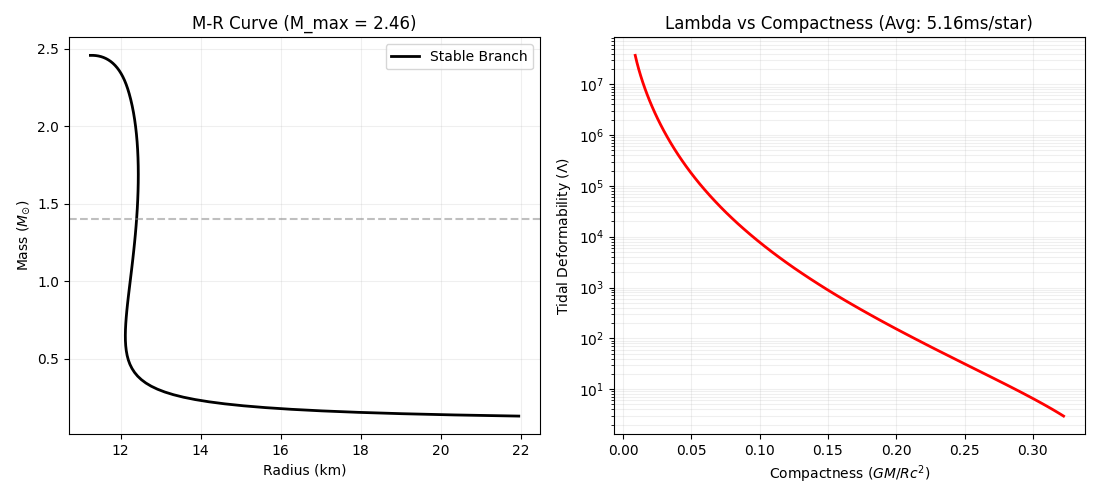

In [8]:
# --- TEST AND BENCHMARK ---
theta = [34.495, 3.446, 3.572, 2.887]
rho_range = np.linspace(14.4, 15.4, 100) 

print(f"--- Timing Test: Solving {len(rho_range)} stars ---")


# Start timing the whole operation
start_total = time.perf_counter()

# This function contains the EoS generation + Fortran Batch Solve
p_array, e_array = build_eos(theta)
m, r, td = TOV4(rho_range, theta, p_array, e_array)

end_total = time.perf_counter()

# --- Statistics Calculation ---
total_time = end_total - start_total
avg_star_time = total_time / len(rho_range)

print("-" * 40)
print(f"Total Execution Time (Curve): {total_time:.6f} seconds")
print(f"Average Time per Star:        {avg_star_time * 1000:.4f} milliseconds")
print("-" * 40)

# Calculate 1.4 M_sun benchmarks
if np.max(m) > 1.4:
    # Note: We use the filtered stable branch from TOV3
    f_r = interp1d(m, r, kind='cubic')
    f_l = interp1d(m, td, kind='cubic')
    r14 = f_r(1.4)
    l14 = f_l(1.4)
    print(f"At 1.4 M_sun: Radius = {r14:.2f} km, Lambda = {l14:.1f}")

# --- PLOTTING ---
plt.figure(figsize=(11, 5))

# Subplot 1: Mass-Radius
plt.subplot(1, 2, 1)
plt.plot(r, m, 'k-', lw=2, label="Stable Branch")
plt.axhline(1.4, color='gray', linestyle='--', alpha=0.5)
plt.xlabel('Radius (km)')
plt.ylabel(r'Mass ($M_{\odot}$)')
plt.title(f'M-R Curve (M_max = {np.max(m):.2f})')
plt.grid(True, alpha=0.2)
plt.legend()

# Subplot 2: Lambda vs Compactness (M/R)
plt.subplot(1, 2, 2)
# Using mass/radius as compactness (dimensionless requires G/c^2 factor)
compactness = (m * 1.4766) / r 
plt.plot(compactness, td, 'r-', lw=2)
plt.yscale('log')
plt.xlabel('Compactness ($GM/Rc^2$)')
plt.ylabel(r'Tidal Deformability ($\Lambda$)')
plt.title(f'Lambda vs Compactness (Avg: {avg_star_time*1000:.2f}ms/star)')
plt.grid(True, which="both", alpha=0.2)

plt.tight_layout()
plt.show()

### <div style= 'color: slateblue'>Create dataset of INPUT and OUTPUT paramters by solving TOV equations with a Piecewise Polytrope

In [14]:
NUM_SAMPLES = 100_000 # Number of EOS samples
# Directory to save/load dataset and models 
# If not defined, model will save in current directory.
save_dir_dataset = f"1_Datasets/TOV4_datasets/{NUM_SAMPLES}samples"
save_dir_training = f"2_Training/TOV4_training/{NUM_SAMPLES}samples"

In [ ]:
# ==========================================================
# 1. Define ranges for input parameters
# ==========================================================
# Generate random EoS parameters
Gamma_samples = np.random.uniform(low=1.4, high=5.0, size=(NUM_SAMPLES, 3))
logp_samples = np.random.uniform(33.5, 34.8, size=(NUM_SAMPLES, 1))
logrho_c_samples = np.random.uniform(14.5, 15.4, size=(NUM_SAMPLES, 1))

# Combine for easier indexing: [logrho_c, logp, G1, G2, G3]
raw_inputs = np.hstack([logrho_c_samples, logp_samples, Gamma_samples])

# ==========================================================
# 2. Solving TOV Loop
# ==========================================================
dataset_list = []

for i in trange(NUM_SAMPLES, desc="Generating Dataset"):
    logrho_c = raw_inputs[i, 0]
    logp = raw_inputs[i, 1]
    g1, g2, g3 = raw_inputs[i, 2], raw_inputs[i, 3], raw_inputs[i, 4]
    
    try:
        # Build EoS table
        p_table, e_table = build_eos([logp, g1, g2, g3])
        
        # TOV4 returns ARRAYS (m, r, td) because it filters for stability
        m_arr, r_arr, td_arr = TOV4([logrho_c], [logp, g1, g2, g3], p_table, e_table)
        
        # Check if we got a valid star back (m_arr won't be empty)
        if len(m_arr) > 0:
            # Extract scalars from the returned arrays
            M, R, L = float(m_arr[0]), float(r_arr[0]), float(td_arr[0])
            
            # Physical validation
            if (0.15 < M < 3.5) and (6.0 < R < 25.0) and (L > 0):
                dataset_list.append([logrho_c, logp, g1, g2, g3, M, R, L])
        
        # Debug first few
        if i < 5 and len(m_arr) > 0:
            print(f"Sample {i}: M={m_arr[0]:.2f}, R={r_arr[0]:.2f}")
        elif i < 5:
            print(f"Sample {i}: No stable star found at this rho_c.")

    except Exception as e:
        # This catches any indexing or math errors during the process
        continue

# ==========================================================
# 4. Finalize and Save
# ==========================================================
final_dataset = np.array(dataset_list)

if len(final_dataset) > 0:
    print(f"Dataset Generation Complete!")
    print(f"Kept {len(final_dataset)} / {NUM_SAMPLES} samples ({len(final_dataset)/NUM_SAMPLES:.1%})")

    os.makedirs(save_dir_dataset, exist_ok=True)
    filename = os.path.join(save_dir_dataset, f"EOS_dataset_{NUM_SAMPLES}files.npy")
    np.save(filename, final_dataset)
    print(f"Dataset saved to: {filename}")
else:
    print("CRITICAL: No samples were kept. Check if logrho_c is consistently inside the stable branch.")


### <div style= 'color: yellow'> PyTorch ML pipeline — load data for sanity check

In [10]:
# Load created dataset
data = np.load(os.path.join(save_dir_dataset, f"EOS_dataset_{NUM_SAMPLES}files.npy"))

# Checking the dataset with added column headers
Column_headers = ['log_rho_c', 'log_p', 'Gamma1', 'Gamma2', 'Gamma3',
                  'Mass_Msun', 'Radius_km', 'TD']
df = pd.DataFrame(data, columns=Column_headers)

# df.head()       # Show first 5 values in each column
df.describe() # Max and min values for each column

# Radius should be within 6 and 24km
# Tidal deformability must be logged

,log_rho_c,log_p,Gamma1,Gamma2,Gamma3,Mass_Msun,Radius_km,TD
count,84422.000000,84422.000000,84422.000000,84422.000000,84422.000000,84422.000000,84422.000000,8.442200e+04
mean,15.001881,34.214516,3.178536,3.234687,3.204517,1.286186,11.367589,2.911123e+05
std,0.242300,0.355892,1.034553,1.032006,1.039440,0.842660,2.535361,1.152244e+06
min,14.500002,33.500028,1.400033,1.400072,1.400010,0.150014,6.209643,7.098442e-01
25%,14.811828,33.929229,2.279083,2.349962,2.305666,0.505616,9.653952,1.327751e+01
50%,15.015408,34.233358,3.160223,3.251642,3.205116,1.166754,11.026697,6.000668e+02
75%,15.208800,34.518038,4.070952,4.127055,4.108179,1.998096,12.531470,3.315856e+04
max,15.399991,34.799995,4.999986,4.999941,4.999975,3.274970,24.999638,2.917107e+07


### <div style= 'color: orange'> PyTorch ML pipeline — prepare data

In [ ]:
# Set device and batch size for training 
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)
BATCH_SIZE = 256

save_dir_training_local = f"2_Training/TOV4_training_local/{NUM_SAMPLES}samples"
# ==========================================================
# 1. Split into training and validation sets (80 / 20)
# ==========================================================
split_idx = int(0.8 * len(data))
train_data = data[:split_idx]
val_data = data[split_idx:]

# ==========================================================
# 2. Convert to Tensor
# ==========================================================
# Inputs: Cols 0 to 4 (5 features: log_rho_c, log_p, Gamma1, Gamma2, Gamma3)
# Output: Col 5 - 7 (Mass, Radius, Tidal Deformability)
X_eos_train = torch.tensor(train_data[:, :5], dtype=torch.float32)  # Training Input
y_eos_train = torch.tensor(train_data[:, 5:8], dtype=torch.float32) # Training Output

X_eos_val = torch.tensor(val_data[:, :5], dtype=torch.float32)      # Validation Input
y_eos_val = torch.tensor(val_data[:, 5:8], dtype=torch.float32)     # Validation Output

# ==========================================================
# 3. Normalize the all the inputs using Z-score (Pressure is already logged)
# ==========================================================
X_eos_mean = X_eos_train.mean(dim=0, keepdim=True)
X_eos_std = X_eos_train.std(dim=0, keepdim=True)
# Save the normalization statistics to be used later for model testing
os.makedirs(save_dir_training_local, exist_ok=True)
torch.save(X_eos_mean, os.path.join(save_dir_training_local, "X_eos_mean.pt"))
torch.save(X_eos_std, os.path.join(save_dir_training_local, "X_eos_std.pt"))
print("Normalization statistics saved.")
X_train_norm = (X_eos_train - X_eos_mean) / X_eos_std
X_val_norm = (X_eos_val - X_eos_mean) / X_eos_std

# ==========================================================
# 4. Normalize the outputs
# ==========================================================
# 4.1. Separate the outputs (Mass, Radius and TD) from the 
# training and validation datasets
y_mass_train, y_radius_train, y_td_train = y_eos_train[:, 0:1], y_eos_train[:, 1:2], y_eos_train[:, 2:3]
y_mass_val, y_radius_val, y_td_val = y_eos_val[:, 0:1], y_eos_val[:, 1:2], y_eos_val[:, 2:3]

# 4.2. Constant Scaling on Mass (M)
MASS_SCALE = 3.5
y_mass_train_norm = y_mass_train / MASS_SCALE
y_mass_val_norm = y_mass_val / MASS_SCALE

# 4.3. Constant Scaling on Radius (R)
RADIUS_SCALE = 25.0
y_radius_train_norm = y_radius_train / RADIUS_SCALE
y_radius_val_norm = y_radius_val / RADIUS_SCALE

# 4.4. Log Scaling on Tidal Deformability (TD)
y_td_train_norm = torch.log10(y_td_train)
y_td_val_norm = torch.log10(y_td_val)

# 4.5 Recombine Outputs
y_train_norm = torch.cat((y_mass_train_norm, y_radius_train_norm, y_td_train_norm), dim=1)
y_val_norm = torch.cat((y_mass_val_norm, y_radius_val_norm, y_td_val_norm), dim=1)

### <div style= 'color: orange'> Range of values of the parameters <b>before</b> scaling and normalizing

In [ ]:
print("Log Central Density min/max:", np.round(train_data[:, 0].min(), 3), np.round(train_data[:, 0].max(), 3))
print("Log Pressure min/max:", np.round(train_data[:, 1].min(), 3), np.round(train_data[:, 1].max(), 3))
print("Gamma 1 min/max:", np.round(train_data[:, 2].min(), 3), np.round(train_data[:, 2].max(), 3))
print("Gamma 2 min/max:", np.round(train_data[:, 3].min(), 3), np.round(train_data[:, 3].max(), 3))
print("Gamma 3 min/max:", np.round(train_data[:, 4].min(), 3), np.round(train_data[:, 4].max(), 3))
print("")
print("Mass min/max:", np.round(train_data[:, 5].min(), 3), np.round(train_data[:, 5].max(), 3))
print("Radius min/max:", np.round(train_data[:, 6].min(), 3), np.round(train_data[:, 6].max(), 3))
print("Tidal Deformability min/max:", np.round(train_data[:, 7].min(), 3), np.round(train_data[:, 7].max(), 3))

train_data.shape

### <div style= 'color: orange'> Range of values of the parameters <b>after</b> scaling and normalizing

In [ ]:
print("Log Central Density min/max:", np.round(X_train_norm[:, 0].min(), 3), np.round(X_train_norm[:, 0].max(), 3))
print("Log Pressure min/max:", np.round(X_train_norm[:, 1].min(), 3), np.round(X_train_norm[:, 1].max(), 3))
print("Gamma 1 min/max:", np.round(X_train_norm[:, 2].min(), 3), np.round(X_train_norm[:, 2].max(), 3))
print("Gamma 2 min/max:", np.round(X_train_norm[:, 3].min(), 3), np.round(X_train_norm[:, 3].max(), 3))
print("Gamma 3 min/max:", np.round(X_train_norm[:, 4].min(), 3), np.round(X_train_norm[:, 4].max(), 3))
print("")
print("Mass min/max:", np.round(y_train_norm[:, 0].min(), 3), np.round(y_train_norm[:, 0].max(), 3))
print("Radius min/max:", np.round(y_train_norm[:, 1].min(), 3), np.round(y_train_norm[:, 1].max(), 3))
print("Tidal Deformability min/max:", np.round(y_train_norm[:, 2].min(), 3), np.round(y_train_norm[:, 2].max(), 3))

train_data.shape

### <div style= 'color: Yellow'>Model Definition

In [11]:
# ==========================================================
# Single Residual Network Block
# ==========================================================
class ResNetBlock(nn.Module): # Custom module
    def __init__(self, hidden_dim): # Constructor of the block
        super().__init__() # Used to define the tools used later
        self.fc = nn.Linear(hidden_dim, hidden_dim) # A fully connected layer
        self.act = nn.GELU() # Gaussian Error Linear Unit activation function
    
    def forward(self, x): # Defines how data flows through the block
        out = self.act(self.fc(x))
        return x + out   # Residual connection


# ==========================================================
# Residual Network
# ==========================================================
class PhysicsEmulator(nn.Module):
    def __init__(self, input_dim=5, hidden_dim=512):
        super().__init__()

        # 1. Initial encoding of all inputs (4 EOS params + logp)
        self.input_layer = nn.Linear(input_dim, hidden_dim)

        # 2. Residual blocks
        self.block1 = ResNetBlock(hidden_dim)
        self.block2 = ResNetBlock(hidden_dim)
        self.block3 = ResNetBlock(hidden_dim)
        self.block4 = ResNetBlock(hidden_dim)

        # 3. Output layers
        self.final_layer = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),  # 512 -> 256
            nn.GELU(),
            nn.Linear(hidden_dim // 2, 3)            # 256 -> 3 outputs
        )

    def forward(self, x):

        # 1. Encode full input
        x_hidden = self.input_layer(x)      # 5 -> 512

        # 2. Residual flow
        x_hidden = self.block1(x_hidden)
        x_hidden = self.block2(x_hidden)
        x_hidden = self.block3(x_hidden)
        x_hidden = self.block4(x_hidden)

        # 3. Prediction
        return self.final_layer(x_hidden)

### <div style= 'color: Orange'>Model Training

In [ ]:
# ==========================================================
# Plotting function
# ==========================================================
def plot_and_save_losses(train_losses, val_losses, filename="loss_curve.svg"):
    """Plots training and validation loss and saves the figure."""

    epochs = range(len(train_losses))

    plt.figure(figsize=(10, 6))
    plt.plot(epochs, train_losses, label='Training Loss', color='blue')
    plt.plot(epochs, val_losses, label='Validation Loss', color='red')
    
    plt.title('Training and Validation Loss Over Time')
    plt.xlabel('Epoch')
    plt.ylabel('Huber Loss (Normalized)')
    plt.yscale('log') # Using log scale for clearer visualization of small losses
    plt.legend()
    plt.grid(True, which="both", ls="--")
    
    try:
        plt.savefig(os.path.join(save_dir_training, filename))
        print(f"Loss plot saved to {filename}", flush=True)
    except Exception as e:
        print(f"ERROR saving plot: {e}", flush=True)
    plt.close()

# ==========================================================
# Set training paramters
# ==========================================================
model = PhysicsEmulator().to(DEVICE)
optimizer = optim.AdamW(model.parameters(), lr=5e-4, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=1000, eta_min=1e-7
            )   # Modulates adaptive learning rate
criterion = nn.HuberLoss()
epochs = 1000   # With early stopping
patience = 100  # Number of epochs to wait for improvement before stopping
patience_counter = 0
best_val_loss = float('inf')

# Lists to store losses for plotting
train_losses = []
val_losses = []

# ==========================================================
# Load training and validation tensors
# ==========================================================
# Ensure Mass and Radius are Torch Tensors
if isinstance(y_train_norm, np.ndarray):
    y_train_norm = torch.from_numpy(y_train_norm).to(torch.float32)
if isinstance(y_val_norm, np.ndarray):
    y_val_norm = torch.from_numpy(y_val_norm).to(torch.float32)

train_loader = DataLoader(TensorDataset(X_train_norm, y_train_norm), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val_norm, y_val_norm), batch_size=BATCH_SIZE, shuffle=False)

# ==========================================================
# Training
# ==========================================================
for epoch in range(epochs):
    # 1. Set model in training mode
    model.train()
    train_loss = 0.0
    for X_b, y_b in train_loader:
        X_b, y_b = X_b.to(DEVICE), y_b.to(DEVICE)
        optimizer.zero_grad()       # Clear previous gradient
        pred = model(X_b)           # Make prediction
        loss = criterion(pred, y_b) # Calculate training loss
        loss.backward()             # Backpropagate loss
        optimizer.step()            # Use optimizer
        train_loss += loss.item()   # Update training loss
    
    train_loss /= len(train_loader)
    
    # 2. Set model in evaluation mode
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for X_b, y_b in val_loader:
            X_b, y_b = X_b.to(DEVICE), y_b.to(DEVICE)
            pred = model(X_b)           # Make prediction
            loss = criterion(pred, y_b) # Calculate validation loss
            val_loss += loss.item()     # Update validation loss
    
    val_loss /= len(val_loader)
    scheduler.step()                    # Update Scheduler
    
    # 3. Append Losses
    train_losses.append(train_loss)
    val_losses.append(val_loss)

    # 4. Early Stopping check
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        # Save the best model weights
        best_model_state = model.state_dict()

    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break
    
    # 5. Calculate and print error in output parameters every 100 epochs
    if epoch % 100 == 0:
        # Calculate the Approximate Physical Error in km
        radius_error_km = np.sqrt(2 * val_loss) * RADIUS_SCALE 
        mass_error = np.sqrt(2 * val_loss) * MASS_SCALE
        td_error_log = np.sqrt(2 * val_loss)  # Since td is log-scaled, this is in log units

        print(f"Epoch {epoch} | Train Loss: {train_loss:.6e} | Val Loss: {val_loss:.6e} | Approx Radius Error: {radius_error_km:.4f} km | Approx Mass Error: {mass_error:.4f} | Approx TD error: {td_error_log:.4f}", flush=True)

        # 6. Plot and save errors
        # Plot every 100 epochs
        if epoch % 100 == 0 and epoch > 0:
            plot_and_save_losses(train_losses, val_losses, filename=f"loss_curve_epoch{epoch}.svg")

# Restore best model
model.load_state_dict(best_model_state)
print(f"Training finished. Best validation loss: {best_val_loss:.10f}")

# 7. Final PLot after training finishes
plot_and_save_losses(train_losses, val_losses, filename="loss_curve_final.svg")

# 8. Saving best model to be used later
torch.save(model.state_dict(), os.path.join(save_dir_training_local, "Best_EOS_Model.pth"))

### <div style= 'color: Yellow'> Testing the Model for a grid of Unseen CD + logp + EOS parameters

In [39]:
# ==========================================================
# 1. Configuration and constants
# ==========================================================
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
save_dir_testing = f"3_Testing/TOV4_tests/{NUM_SAMPLES}samples"
os.makedirs(save_dir_testing, exist_ok=True)

RADIUS_SCALE = 25.0
MASS_SCALE = 3.5

MODEL_NO = 1

# ==========================================================
# 2. Set ranges for the parameters of the EOS for the curves to be tested.
#    Should be within training range. Values outside the training range would be extrapolation
# ==========================================================
Gamma1_values = [1.6, 1.8, 2.0, 2.2, 2.4, 2.6, 2.8, 3.0, 3.2, 3.4, 3.6, 3.8, 4.0, 4.2, 4.4, 4.6, 4.8]
Gamma2_values = [1.6, 1.8, 2.0, 2.2, 2.4, 2.6, 2.8, 3.0, 3.2, 3.4, 3.6, 3.8, 4.0, 4.2, 4.4, 4.6, 4.8]
Gamma3_values = [1.6, 1.8, 2.0, 2.2, 2.4, 2.6, 2.8, 3.0, 3.2, 3.4, 3.6, 3.8, 4.0, 4.2, 4.4, 4.6, 4.8]

logp_values = [33.6, 33.8, 34.0, 34.2, 34.4, 34.6, 34.8]

logrho_c_array = np.linspace(14.5, 15.4, 100) # sample different central densities <------------------------------------

# Randomly select combinations of (Γ1,Γ2,Γ3,logp)
param_combinations = list(itertools.product(Gamma1_values, Gamma2_values, Gamma3_values, logp_values))
sampled_combinations = random.sample(param_combinations, 10)  # Number of random combos <------------------------------

print (f"Testing on {len(sampled_combinations)} random EOS parameter combinations")
# ==========================================================
# 3. Prepare models and Scalars
# ==========================================================
# Load model and call to device
model = PhysicsEmulator().to(DEVICE)
model.load_state_dict(torch.load(os.path.join(save_dir_training, "Best_EOS_Model.pth"), map_location=DEVICE))
model.eval()    # Set model in evaluation mode

# Load the means and stds for normalization from training
X_mean = torch.load(os.path.join(save_dir_training, "X_eos_mean.pt")).to(DEVICE)
X_std = torch.load(os.path.join(save_dir_training, "X_eos_std.pt")).to(DEVICE)

Testing on 10 random EOS parameter combinations


/tmp/ipykernel_6730/1548537175.py:11: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig2, ax2 = plt.subplots(figsize=(8, 6))


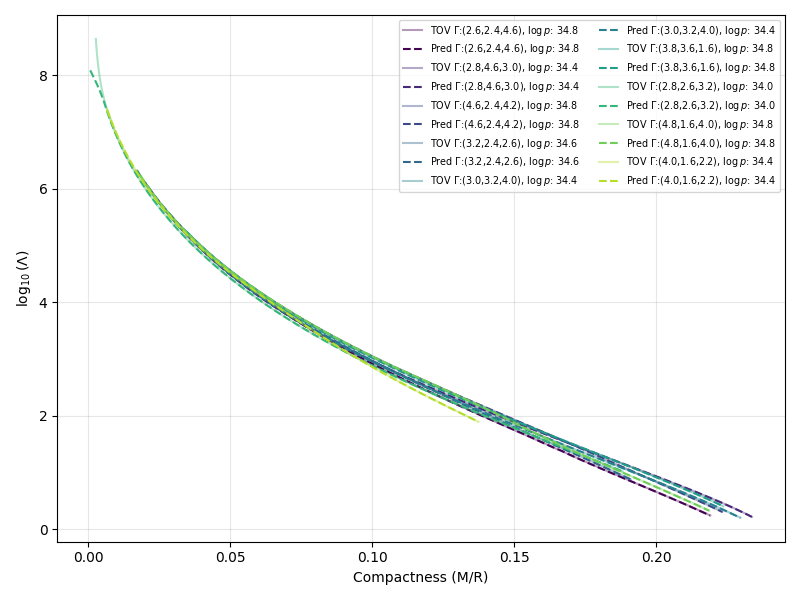

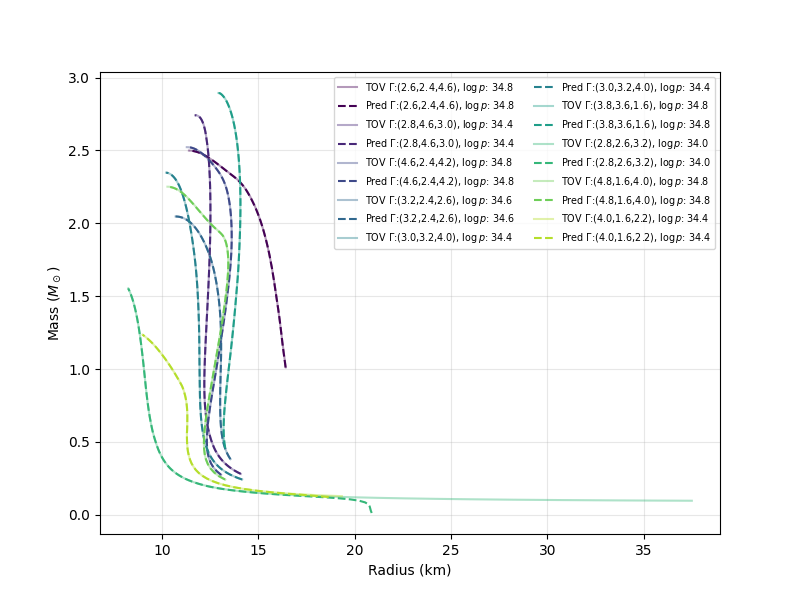

In [40]:
# ==========================================================
# 4. Evaluation and plot loop
# ==========================================================
# Initialize master lists for metrics
all_orig_M, all_pred_M = [], []
all_orig_R, all_pred_R = [], []
all_orig_TD, all_pred_TD = [], []


fig1, ax1 = plt.subplots(figsize=(8, 6))
fig2, ax2 = plt.subplots(figsize=(8, 6))

colors = plt.cm.viridis(np.linspace(0, 1, len(sampled_combinations)))

for color, (Gamma1, Gamma2, Gamma3, logp) in zip(colors, sampled_combinations):
    
    # 1. Generate Ground Truth
    p_array, e_array = build_eos([logp, Gamma1, Gamma2, Gamma3])
    M_orig, R_orig, TD_orig = TOV4(logrho_c_array, [logp, Gamma1, Gamma2, Gamma3], p_array, e_array)

    # --- NEW: Sync the lengths ---
    # Find how many points the TOV solver actually returned
    n_valid = len(M_orig) 
    # Slice the density array and the NN inputs to match the TOV output
    current_rho_slice = logrho_c_array[:n_valid]
    # -----------------------------

    # 2. Generate NN Predictions using the SLICED densities
    logp_repeated = np.full(n_valid, logp)
    g1_rep, g2_rep, g3_rep = [np.full(n_valid, g) for g in [Gamma1, Gamma2, Gamma3]]
    
    input_stack = np.stack([current_rho_slice, logp_repeated, g1_rep, g2_rep, g3_rep], axis=1)
    input_norm = (torch.tensor(input_stack, dtype=torch.float32).to(DEVICE) - X_mean) / X_std
    
    with torch.no_grad():
        preds = model(input_norm).cpu().numpy()
    
    M_pred = preds[:, 0] * MASS_SCALE
    R_pred = preds[:, 1] * RADIUS_SCALE
    TD_pred_log = preds[:, 2]

    # 3. SYNCHRONIZED FILTERING (Now shapes will match: 58 vs 58)
    mask = (
        np.isfinite(M_orig) & np.isfinite(R_orig) & (TD_orig > 0) &
        (M_orig > 0.15) & (M_orig < 3.5) &
        (R_orig > 6.0) & (R_orig < 25.0) &
        np.isfinite(M_pred) & np.isfinite(R_pred)
    )

    # Only keep points where the mask is True
    M_orig_filt, M_pred_filt = M_orig[mask], M_pred[mask]
    R_orig_filt, R_pred_filt = R_orig[mask], R_pred[mask]
    TD_orig_filt, TD_pred_filt = np.log10(TD_orig[mask]), TD_pred_log[mask]

    if len(M_orig_filt) == 0:
        continue # Skip if no valid points in this EoS

    # 4. Store results for metrics
    all_orig_M.append(M_orig)
    all_pred_M.append(M_pred)
    all_orig_R.append(R_orig)
    all_pred_R.append(R_pred)
    all_orig_TD.append(np.log10(TD_orig)) # Store in log space to match prediction
    all_pred_TD.append(TD_pred_log)

    # 5. Plotting
    label = rf"$\Gamma$:({Gamma1},{Gamma2},{Gamma3}), $\log p$: {logp}"
    
    # Plot M-R
    ax1.plot(R_orig, M_orig, '-', color=color, alpha=0.4, label=f"TOV {label}")
    ax1.plot(R_pred, M_pred, '--', color=color, label=f"Pred {label}")

    # Plot TD-Compactness
    ax2.plot(M_orig / R_orig, np.log10(TD_orig), "-", color=color, alpha=0.4, label=f"TOV {label}")
    ax2.plot(M_pred / R_pred, TD_pred_log, "--", color=color, label=f"Pred {label}")

   

# Formatting Final touches
for ax in [ax1, ax2]:
    ax.grid(alpha=0.3)
    ax.legend(fontsize="x-small", ncol=2, loc='best')

ax1.set_xlabel("Radius (km)"); ax1.set_ylabel(r"Mass ($M_\odot$)")
ax2.set_xlabel("Compactness (M/R)"); ax2.set_ylabel(r"$\log_{10}(\Lambda)$")

plt.tight_layout()
plt.show()

### <div style= 'color: yellow'> Model Metrics

In [41]:
# ==========================================================
# 5. Calculate Metrics
# ==========================================================
# Flatten lists into single numpy arrays
orig_mass_all = np.concatenate(all_orig_M)
pred_mass_all = np.concatenate(all_pred_M)
orig_radius_all = np.concatenate(all_orig_R)
pred_radius_all = np.concatenate(all_pred_R)
orig_td_all = np.concatenate(all_orig_TD)
pred_td_all = np.concatenate(all_pred_TD)

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Mass Metrics
mae_mass = mean_absolute_error(orig_mass_all, pred_mass_all)
rmse_mass = np.sqrt(mean_squared_error(orig_mass_all, pred_mass_all))
r2_mass = r2_score(orig_mass_all, pred_mass_all)

# Radius Metrics
mae_radius = mean_absolute_error(orig_radius_all, pred_radius_all)
rmse_radius = np.sqrt(mean_squared_error(orig_radius_all, pred_radius_all))
r2_radius = r2_score(orig_radius_all, pred_radius_all)

# TD Metrics
mae_td = mean_absolute_error(orig_td_all, pred_td_all)
rmse_td = np.sqrt(mean_squared_error(orig_td_all, pred_td_all))
r2_td = r2_score(orig_td_all, pred_td_all)

# Combined Normalized RMSE (CV - Coefficient of Variation)
norm_rmse = np.mean([
    rmse_radius / np.mean(orig_radius_all),
    rmse_mass / np.mean(orig_mass_all),
    rmse_td / np.abs(np.mean(orig_td_all)) # abs() in case log mean is negative
])

print(f"\n--- Model Performance Metrics ---")
print(f"Radius: MAE={mae_radius:.4f}, RMSE={rmse_radius:.4f}, R²={r2_radius:.4f}")
print(f"Mass:   MAE={mae_mass:.4f}, RMSE={rmse_mass:.4f}, R²={r2_mass:.4f}")
print(f"TD (log): MAE={mae_td:.4f}, RMSE={rmse_td:.4f}, R²={r2_td:.4f}")
print(f"Combined normalized RMSE = {norm_rmse:.4f}")


--- Model Performance Metrics ---
Radius: MAE=0.0878, RMSE=0.9443, R²=0.8516
Mass:   MAE=0.0008, RMSE=0.0052, R²=1.0000
TD (log): MAE=0.0028, RMSE=0.0291, R²=0.9997
Combined normalized RMSE = 0.0296


In [49]:
# ==========================================================
# Save Metrics to a Text file
# ==========================================================
output_file = os.path.join(save_dir_testing, f"Model_metrics_{len(sampled_combinations)}EOSs.txt")

with open(output_file, "w") as f:
    f.write(f"Mass, Radius and TD prediction metrics {len(sampled_combinations)} EOSs\n")
    f.write("==============================================\n")

    f.write("Mass Prediction Metrics:\n")
    f.write(f"MAE   : {mae_mass:.6f}\n")
    f.write(f"RMSE  : {rmse_mass:.6f}\n")
    f.write(f"R^2   : {r2_mass:.6f}\n")
    f.write("\n")

    f.write("Radius Prediction Metrics:\n")
    f.write(f"MAE   : {mae_radius:.6f}\ n")
    f.write(f"RMSE  : {rmse_radius:.6f}\n")
    f.write(f"R^2   : {r2_radius:.6f}\n")
    f.write("\n")

    f.write("Tidal Deformability Prediction Metrics:\n")
    f.write(f"MAE   : {mae_td:.6f}\n")
    f.write(f"RMSE  : {rmse_td:.6f}\n")
    f.write(f"R^2   : {r2_td:.6f}\n")
    f.write("\n")

    f.write(f"Norm RMSE : {norm_rmse:.6f}\n")
    
print(f"Metrics saved to {output_file}")

Metrics saved to 3_Testing/TOV4_tests/100000samples/Model_metrics_10EOSs.txt


### <div style= 'color: Yellow'> Benchmarking model

#### Timing the TOV solver against the Model prediction for an entire stellar sequence
i.e. Time required to compute an entire M–R curve for one EOS.

In [50]:
# ==========================================================
# Reproducibility
# ==========================================================
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ==========================================================
# Define Benchmark
# ==========================================================
def benchmark(model, sampled_combinations, logrho_c_array,
              X_mean, X_std, DEVICE,
              MASS_SCALE, RADIUS_SCALE):

    tov_total = 0.0
    model_total = 0.0
    N = len(logrho_c_array)

    for (Gamma1, Gamma2, Gamma3, logp) in sampled_combinations:

        # --- TOV2 Timing ---
        # Ensure TOV2 is the vectorized version we just optimized
        start_tov = time.perf_counter()
        p_array, e_array = build_eos([logp, Gamma1, Gamma2, Gamma3])
        _ = TOV4(logrho_c_array, [logp, Gamma1, Gamma2, Gamma3], p_array, e_array)
        tov_total += time.perf_counter() - start_tov

        # --- Batched Neural Emulator ---
        start_model = time.perf_counter()

        x = torch.tensor(
            np.column_stack([
                logrho_c_array,
                np.full(N, logp),
                np.full(N, Gamma1),
                np.full(N, Gamma2),
                np.full(N, Gamma3)
            ]),
            dtype=torch.float32
        ).to(DEVICE)

        x_norm = (x - X_mean) / X_std

        with torch.no_grad():
            pred = model(x_norm)

        # CRITICAL: Ensures GPU finished before stopping clock
        if DEVICE.type == "cuda":
            torch.cuda.synchronize()

        model_total += time.perf_counter() - start_model

    n_curves = len(sampled_combinations)
    tov_avg = tov_total / n_curves
    model_avg = model_total / n_curves
    return {
        "tov_avg": tov_avg,
        "model_avg": model_avg,
        "speedup": tov_avg / model_avg
    }

MEDIAN Benchmarking

In [52]:
# ==========================================================
# Run Benchmark with Warm-up and Median Statistics
# ==========================================================
N_RUNS = 10  # Increased slightly for better median stability
tov_avgs = []
model_avgs = []
speedups = []

print("Starting Benchmark...")

# 1. WARM-UP PHASE
# We run it once and ignore the results to "wake up" the hardware
# and initialize CUDA kernels/Python caches.
_ = benchmark(
    model, sampled_combinations, logrho_c_array,
    X_mean, X_std, DEVICE, MASS_SCALE, RADIUS_SCALE
)
print("Warm-up complete. Starting timed trials...")

# 2. TIMED TRIALS
for i in range(N_RUNS):
    res = benchmark(
        model,
        sampled_combinations,
        logrho_c_array,
        X_mean,
        X_std,
        DEVICE,
        MASS_SCALE,
        RADIUS_SCALE
    )
    
    tov_avgs.append(res["tov_avg"])
    model_avgs.append(res["model_avg"])
    speedups.append(res["speedup"])
    
    print(f"  Run {i+1}/{N_RUNS} complete (Speedup: {res['speedup']:.1f}x)")

# 3. COMPUTE MEDIAN STATISTICS
# Median is robust against "spikes" caused by background OS tasks
tov_median = np.median(tov_avgs)
model_median = np.median(model_avgs)
speedup_median = np.median(speedups)

# Optional: Calculate Standard Deviation to see how "noisy" your system is
speedup_std = np.std(speedups)

# ==========================================================
# Final Results Printout
# ==========================================================
print("\n" + "="*20 + " Final Benchmark Results " + "="*20)
print(f"Number of EOS tested: {len(sampled_combinations)}")
print(f"Samples per curve:    {len(logrho_c_array)}")
print(f"Number of trials:     {N_RUNS} (after 1 warm-up)")
print("-" * 65)

print(f"Median TOV curve time:   {tov_median:.4f} s")
print(f"Median Model curve time: {model_median:.6f} s")
print(f"\n---> Speedup Factor: {speedup_median:.1f}x ± {speedup_std:.1f}x faster")
print("=" * 65)

Starting Benchmark...
Warm-up complete. Starting timed trials...
  Run 1/10 complete (Speedup: 78.0x)
  Run 2/10 complete (Speedup: 44.3x)
  Run 3/10 complete (Speedup: 134.7x)
  Run 4/10 complete (Speedup: 85.7x)
  Run 5/10 complete (Speedup: 71.7x)
  Run 6/10 complete (Speedup: 66.8x)
  Run 7/10 complete (Speedup: 123.1x)
  Run 8/10 complete (Speedup: 97.5x)
  Run 9/10 complete (Speedup: 85.5x)
  Run 10/10 complete (Speedup: 75.5x)

==================== Final Benchmark Results ====================
Number of EOS tested: 10
Samples per curve:    100
Number of trials:     10 (after 1 warm-up)
-----------------------------------------------------------------
Median TOV curve time:   0.4751 s
Median Model curve time: 0.005903 s

---> Speedup Factor: 81.7x ± 25.2x faster


In [64]:
save_dir_benchmarking = f"4_Benchmarking/TOV4_benchmarks/{NUM_SAMPLES}samples"
os.makedirs(save_dir_benchmarking, exist_ok=True)

output_file = os.path.join(save_dir_benchmarking, f"Benchmark_metrics_{len(sampled_combinations)}EOSs.txt")

with open(output_file, "w") as f:
    f.write(f"Benchmark metrics for {len(sampled_combinations)} EOSs\n")
    f.write("================================\n")

    f.write("\n" + "="*20 + " Final Benchmark Results " + "="*20 + "\n")
    f.write(f"Number of EOS tested: {len(sampled_combinations)}\n")
    f.write(f"Samples per curve:    {len(logrho_c_array)}\n")
    f.write(f"Number of trials:     {N_RUNS} (after 1 warm-up)\n")
    f.write("-" * 65 + "\n")

    f.write(f"Median TOV curve time: {tov_median:.6f} seconds\n")
    f.write(f"Median Model curve time: {model_median:.6f} seconds\n")

    f.write(f"\n--->Speedup Factor: {speedup_median:.1f}x ± {speedup_std:.1f}x faster\n")
    f.write("=" * 65)
    
print(f"Metrics saved to {output_file}")


Metrics saved to 4_Benchmarking/TOV4_benchmarks/100000samples/Benchmark_metrics_10EOSs.txt
